In [19]:
#!pip uninstall google-cloud-aiplatform -y
#!pip install --upgrade google-cloud-aiplatform


In [20]:
# ============================
# 1. Bibliotecas e configurações
# ============================
from google.cloud import bigquery, storage, aiplatform
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import joblib
import os

# ============================
# 2. Configurações
# ============================
PROJECT_ID = "br-pruebadeconcepto-cld-01"
LOCATION = "southamerica-east1"
BUCKET_NAME = "demo4mldata"

GCS_PREDICTOR_PATH = "modelos/predictor.py"
GCS_REQS_PATH = "modelos/requirements.txt"

LOCAL_PREDICTOR_FILE = "predictor.py"
LOCAL_REQUIREMENTS = "requirements.txt"

LOCAL_MODEL_FILE = "modelos/model.pkl"
GCS_MODEL_PATH = "modelos/model.pkl"


In [ ]:
# ============================
# 3. Coleta de dados do BigQuery
# ============================
print("Carregando dados do BigQuery...")
bq_client = bigquery.Client(project=PROJECT_ID)

query = """
SELECT trip_date, unique_trip_count
FROM `br-pruebadeconcepto-cld-01.mprs.chicagotaxi_agrupado`
ORDER BY trip_date
"""

df = bq_client.query(query).to_dataframe()
df['trip_date'] = pd.to_datetime(df['trip_date'])
df.set_index('trip_date', inplace=True)
df = df.asfreq('D')
df['unique_trip_count'] = df['unique_trip_count'].interpolate()


Carregando dados do BigQuery...


In [4]:
# ============================
# 4. Treinamento SARIMA
# ============================
print("Treinando modelo SARIMA...")
n_test = 30
train = df['unique_trip_count'][:-n_test]
test = df['unique_trip_count'][-n_test:]

stepwise_model = auto_arima(train,
                             start_p=0, start_q=0,
                             max_p=3, max_q=3,
                             start_P=0, start_Q=0,
                             max_P=2, max_Q=2,
                             d=None, D=None,
                             seasonal=True,
                             m=7,
                             trace=True,
                             error_action='ignore',
                             suppress_warnings=True,
                             stepwise=True)

forecast = stepwise_model.predict(n_periods=n_test)
forecast = pd.Series(forecast, index=test.index)

# ============================
# 5. Avaliação
# ============================
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = mean_absolute_percentage_error(test, forecast)

print(f"\nMAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape*100:.2f}%")

Treinando modelo SARIMA...
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=84160.418, Time=0.10 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=82565.073, Time=0.63 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=83210.992, Time=0.71 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=84158.422, Time=0.06 sec
 ARIMA(1,1,0)(0,0,0)[7] intercept   : AIC=84085.466, Time=0.13 sec
 ARIMA(1,1,0)(2,0,0)[7] intercept   : AIC=82154.983, Time=1.31 sec
 ARIMA(1,1,0)(2,0,1)[7] intercept   : AIC=80758.774, Time=13.66 sec
 ARIMA(1,1,0)(1,0,1)[7] intercept   : AIC=80851.539, Time=5.44 sec
 ARIMA(1,1,0)(2,0,2)[7] intercept   : AIC=inf, Time=11.04 sec
 ARIMA(1,1,0)(1,0,2)[7] intercept   : AIC=80641.084, Time=9.49 sec
 ARIMA(1,1,0)(0,0,2)[7] intercept   : AIC=82777.556, Time=1.30 sec
 ARIMA(1,1,0)(0,0,1)[7] intercept   : AIC=83217.550, Time=0.66 sec
 ARIMA(0,1,0)(1,0,2)[7] intercept   : AIC=80579.573, Time=9.69 sec
 ARIMA(0,1,0)(0,0,2)[7] intercept   : AIC=82805.076, Time=0.98 

Salvando modelo localmente em: modelos/model.pkl
                 data      previsao  desvio_padrao  minimo_previsto  \
2023-12-02 2024-01-01  14553.148265    6877.135893      1073.961915   
2023-12-03 2024-01-02  14048.731867    8727.119707     -3056.422760   
2023-12-04 2024-01-03  18027.394896    9598.094896      -784.871099   
2023-12-05 2024-01-04  18985.586490   10066.558435      -744.868043   
2023-12-06 2024-01-05  19551.073689   10340.942863      -717.174323   

            maximo_previsto  
2023-12-02     28032.334615  
2023-12-03     31153.886493  
2023-12-04     36839.660892  
2023-12-05     38716.041022  
2023-12-06     39819.321701  


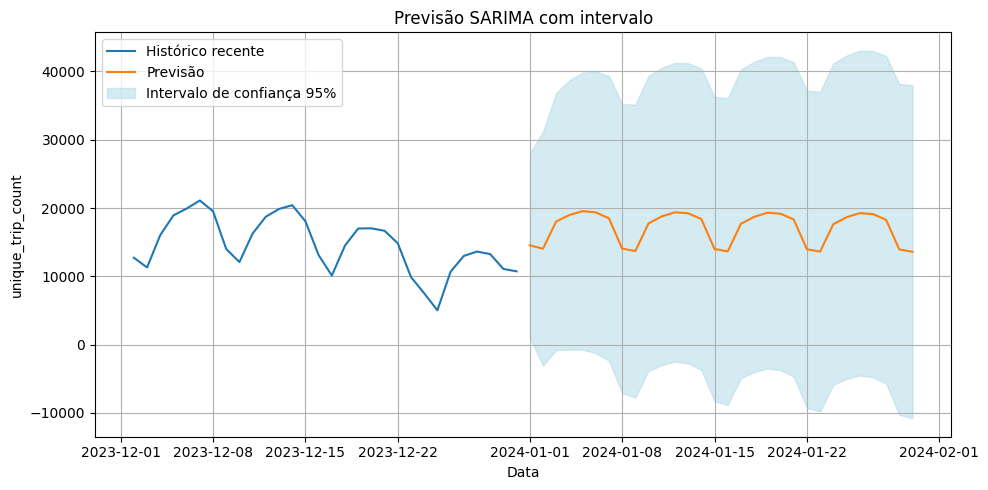

In [13]:
# ============================
# 6. Salvando o modelo
# ============================
# Cria o diretório 'modelos' se ele não existir
os.makedirs(os.path.dirname(LOCAL_MODEL_FILE), exist_ok=True)

print(f"Salvando modelo localmente em: {LOCAL_MODEL_FILE}")
joblib.dump(stepwise_model, LOCAL_MODEL_FILE)
# ============================
# 7. Previsões futuras
# ============================
n_periods_future = 30
forecast_future, conf_int = stepwise_model.predict(n_periods=n_periods_future, return_conf_int=True)
last_date = df.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=n_periods_future, freq='D')

forecast_df = pd.DataFrame({
    'data': future_dates,
    'previsao': forecast_future,
    'desvio_padrao': (conf_int[:, 1] - conf_int[:, 0]) / (2 * 1.96),
    'minimo_previsto': conf_int[:, 0],
    'maximo_previsto': conf_int[:, 1]
})

print(forecast_df.head())

# ============================
# 8. Plotagem
# ============================
plt.figure(figsize=(10, 5))
plt.plot(df.index[-30:], df['unique_trip_count'].tail(30), label='Histórico recente')
plt.plot(forecast_df['data'], forecast_df['previsao'], label='Previsão')
plt.fill_between(forecast_df['data'], forecast_df['minimo_previsto'], forecast_df['maximo_previsto'],
                 color='lightblue', alpha=0.5, label='Intervalo de confiança 95%')
plt.legend()
plt.title('Previsão SARIMA com intervalo')
plt.xlabel('Data')
plt.ylabel('unique_trip_count')
plt.grid(True)
plt.tight_layout()
plt.savefig("forecast_plot.png")
plt.show()

In [12]:
# ============================
# 9. Criando o arquivo predictor.py
# ============================
print("Criando arquivo predictor.py...")

predictor_code = '''
import joblib
import numpy as np
import os
import logging
from pmdarima.arima import ARIMA
from flask import Flask, request, jsonify
from google.cloud import storage

# Configura o logger
logging.basicConfig(level=logging.INFO)

class Predictor:
    """
    Classe para carregar o modelo SARIMA e fazer previsões.
    """
    def __init__(self, model_dir):
        self.model = None
        # A variável de ambiente AIP_STORAGE_URI aponta para o diretório de artefatos
        gcs_uri = os.environ.get("AIP_STORAGE_URI")
        local_model_path = os.path.join(model_dir, "model.pkl")

        if gcs_uri:
            try:
                logging.info(f"Iniciando download do modelo do GCS: {gcs_uri}")
                # Remove o prefixo "gs://" da URI
                uri_path = gcs_uri[5:]
                bucket_name = uri_path.split('/')[0]
                blob_prefix = '/'.join(uri_path.split('/')[1:])
                
                # Constrói o caminho completo do blob
                full_blob_path = os.path.join(blob_prefix, "model.pkl")
                
                storage_client = storage.Client()
                bucket = storage_client.bucket(bucket_name)
                blob = bucket.blob(full_blob_path)
                
                # Baixa o modelo do GCS para o diretório local do contêiner
                blob.download_to_filename(local_model_path)
                logging.info("✔ Download do modelo concluído com sucesso.")
                
                self.model = joblib.load(local_model_path)
                logging.info("✔ Modelo SARIMA carregado com sucesso.")
            except Exception as e:
                logging.error(f"❌ Erro ao carregar o modelo do GCS: {str(e)}")
                self.model = None
        else:
            # Lógica para carregar localmente (teste local)
            try:
                logging.info(f"Carregando modelo localmente de: {local_model_path}")
                self.model = joblib.load(local_model_path)
                logging.info("✔ Modelo SARIMA carregado com sucesso localmente.")
            except Exception as e:
                logging.error(f"❌ Erro ao carregar o modelo localmente: {str(e)}")
                self.model = None

    def predict(self, n_periods: int):
        """
        Faz a previsão usando o modelo SARIMA para um número especificado de períodos.
        """
        if self.model is None:
            raise RuntimeError("O modelo não foi carregado corretamente.")

        forecast, conf_int = self.model.predict(n_periods=n_periods, return_conf_int=True)
        return {
            "predictions": forecast.tolist(),
            "confidence_interval": conf_int.tolist()
        }

# Inicializa a aplicação Flask e a instância do predictor
app = Flask(__name__)
model_dir = os.environ.get("AIP_MODEL_DIR", ".")
predictor_instance = Predictor(model_dir)

@app.route(os.environ.get("AIP_HEALTH_ROUTE", "/health"), methods=["GET"])
def health_check():
    """Endpoint de verificação de saúde."""
    if predictor_instance and predictor_instance.model is not None:
        logging.info("✔ Health check bem-sucedido. O modelo está pronto.")
        return "ok", 200
    else:
        logging.warning("⚠️ Health check falhou. O modelo ainda não está pronto.")
        return "Not OK - Model not loaded", 503

@app.route(os.environ.get("AIP_PREDICT_ROUTE", "/predict"), methods=["POST"])
def predict_route():
    """Endpoint para predições."""
    if not predictor_instance or predictor_instance.model is None:
        return jsonify({"error": "O modelo não está pronto para previsões."}), 503

    data = request.get_json()
    
    # Verifica se a requisição contém a chave 'instances' e se ela não está vazia
    if not data or "instances" not in data or not data["instances"]:
        return jsonify({
            "error": "Corpo da requisição inválido. Espera-se um JSON com a chave 'instances' contendo 'n_periods'."
        }), 400

    try:
        # Extrai o valor de 'n_periods' da primeira instância da lista
        # A requisição deve ser: {"instances": [{"n_periods": 12}]}
        n_periods = data["instances"][0].get("n_periods")
        
        # Validação simples para garantir que o valor é um inteiro positivo
        if not isinstance(n_periods, int) or n_periods <= 0:
            return jsonify({
                "error": "Valor para 'n_periods' inválido. Espera-se um inteiro positivo."
            }), 400

        # Chama o método predict com o novo valor
        predictions = predictor_instance.predict(n_periods)
        return jsonify(predictions)
    except Exception as e:
        logging.error(f"Erro durante a previsão: {str(e)}")
        return jsonify({"error": f"Falha na previsão: {str(e)}"}), 500
'''

with open(LOCAL_PREDICTOR_FILE, "w") as f:
    f.write(predictor_code.strip())

print("✔ Arquivo predictor.py criado com sucesso.")



Criando arquivo predictor.py...
✔ Arquivo predictor.py criado com sucesso.


In [14]:
# !docker build -t southamerica-east1-docker.pkg.dev/br-pruebadeconcepto-cld-01/vertex-custom-containers/sarima-predictor:latest .

In [15]:
# !docker push southamerica-east1-docker.pkg.dev/br-pruebadeconcepto-cld-01/vertex-custom-containers/sarima-predictor:latest

In [16]:
# !docker build -t sarima-predictor:local .

In [17]:
# !docker run -p 8081:8080 -e AIP_MODEL_DIR=/app/modelos -v $(pwd)/modelos:/app/modelos sarima-predictor:local

In [23]:
# ============================
# 10. Upload de arquivos para o GCS
# ============================
print("Fazendo upload dos arquivos para o Cloud Storage...")
storage_client = storage.Client(project=PROJECT_ID)
bucket = storage_client.bucket(BUCKET_NAME)

def upload_to_gcs(local_path, gcs_path):
    blob = bucket.blob(gcs_path)
    blob.upload_from_filename(local_path)
    print(f"✔ Enviado: gs://{BUCKET_NAME}/{gcs_path}")

upload_to_gcs(GCS_MODEL_PATH, GCS_MODEL_PATH)
upload_to_gcs(LOCAL_REQUIREMENTS, GCS_REQS_PATH)
upload_to_gcs(LOCAL_PREDICTOR_FILE, GCS_PREDICTOR_PATH)


Fazendo upload dos arquivos para o Cloud Storage...
✔ Enviado: gs://demo4mldata/modelos/model.pkl
✔ Enviado: gs://demo4mldata/modelos/requirements.txt
✔ Enviado: gs://demo4mldata/modelos/predictor.py


In [24]:
# # ============================
# # 11. Criando modelo.yaml
# # ============================
# yaml_content = f"""
# name: sarima-model
# description: Modelo SARIMA para previsão de corridas
# artifact_uri: gs://{BUCKET_NAME}/{GCS_MODEL_PATH}
# container_spec:
#   image_uri: us-docker.pkg.dev/vertex-ai/prediction/sklearn-cpu.0-24:latest
#   command: []
# """

# with open(LOCAL_YAML_FILE, "w") as f:
#     f.write(yaml_content.strip())

# print("✔ Arquivo modelo.yaml criado com sucesso.")

# upload_to_gcs(LOCAL_YAML_FILE, GCS_YAML_PATH)

In [25]:
# ============================
# 12. Registro no Vertex AI
# ============================

print("Registrando modelo no Vertex AI...")

from google.cloud import aiplatform
'''
aiplatform.init(project=PROJECT_ID, location=LOCATION)

model = aiplatform.CustomPythonModel(
    display_name="sarima-model",
    model_path=f"gs://{BUCKET_NAME}/modelos/model.pkl",
    python_package_gcs_uri=f"gs://{BUCKET_NAME}/modelos/",
    serving_container_image_uri="southamerica-east1-docker.pkg.dev/br-pruebadeconcepto-cld-01/vertex-custom-containers/sarima-predictor:latest",
    #serving_container_image_uri="us-docker.pkg.dev/vertex-ai/prediction/sklearn-cpu.1-0:latest",
    requirements=["pmdarima", "joblib", "numpy"]
)

model.upload()



'''
aiplatform.init(project="br-pruebadeconcepto-cld-01", location="southamerica-east1")

model = aiplatform.Model.upload(
    display_name="sarima-model", 
    #display_name="sarima-model",
    artifact_uri="gs://demo4mldata/modelos/",  # pasta onde está o model.pkl
    serving_container_image_uri="southamerica-east1-docker.pkg.dev/br-pruebadeconcepto-cld-01/vertex-custom-containers/sarima-predictor:latest"
    #serving_container_image_uri="us-docker.pkg.dev/vertex-ai/prediction/sklearn-cpu.1-0:latest"
)
print(f"✔ Modelo registrado com sucesso! ID: {model.resource_name}")

Registrando modelo no Vertex AI...
Creating Model
Create Model backing LRO: projects/538940429074/locations/southamerica-east1/models/5077412755674234880/operations/6429536630175956992
Model created. Resource name: projects/538940429074/locations/southamerica-east1/models/5077412755674234880@1
To use this Model in another session:
model = aiplatform.Model('projects/538940429074/locations/southamerica-east1/models/5077412755674234880@1')
✔ Modelo registrado com sucesso! ID: projects/538940429074/locations/southamerica-east1/models/5077412755674234880


In [27]:
# ============================
# 13. Criando o Endpoint
# ============================

aiplatform.init(project=PROJECT_ID, location=LOCATION)

# Criar Endpoint
endpoint = aiplatform.Endpoint.create(display_name="sarima-endpoint")
print(f"✔ Endpoint criado: {endpoint.resource_name}")

# Listar todos os modelos
models = aiplatform.Model.list(order_by="create_time desc")

# Buscar o modelo pelo nome
model = next((m for m in models if m.display_name == "sarima-model"), None)
if model is None:
    raise ValueError("❌ Modelo 'sarima-model' não encontrado.")
print(f"✔ Modelo encontrado: {model.resource_name}")

Creating Endpoint
Create Endpoint backing LRO: projects/538940429074/locations/southamerica-east1/endpoints/6667953082275463168/operations/5120115038517985280
Endpoint created. Resource name: projects/538940429074/locations/southamerica-east1/endpoints/6667953082275463168
To use this Endpoint in another session:
endpoint = aiplatform.Endpoint('projects/538940429074/locations/southamerica-east1/endpoints/6667953082275463168')
✔ Endpoint criado: projects/538940429074/locations/southamerica-east1/endpoints/6667953082275463168
✔ Modelo encontrado: projects/538940429074/locations/southamerica-east1/models/5077412755674234880


In [29]:
# ============================
# 14. Fazer o deploy no endpoint
# ============================

model.deploy(
    endpoint=endpoint,
    deployed_model_display_name="sarima-model",
    machine_type="n1-standard-2",
    traffic_split={"0": 100}
)

Deploying model to Endpoint : projects/538940429074/locations/southamerica-east1/endpoints/6667953082275463168
Deploy Endpoint model backing LRO: projects/538940429074/locations/southamerica-east1/endpoints/6667953082275463168/operations/6721144706048196608
Endpoint model deployed. Resource name: projects/538940429074/locations/southamerica-east1/endpoints/6667953082275463168


resource name: projects/538940429074/locations/southamerica-east1/endpoints/6667953082275463168

In [30]:
# ============================
# 15. Testando a API
# ============================

# O modelo de série temporal agora espera o número de períodos a prever,
# e não dados de entrada.
n_periods_to_predict = 12

# Modifique a variável 'instances' para o novo formato.
# O payload deve ser uma lista contendo um dicionário com a chave "n_periods".
instances = [{"n_periods": n_periods_to_predict}]

# A chamada para endpoint.predict() permanece a mesma,
# mas agora usa o novo formato de 'instances'.
response = endpoint.predict(instances=instances)
print("📈 Previsão:", response.predictions)

📈 Previsão: [14553.14826475918, 14048.73186675466, 18027.39489631503, 18985.58648950724, 19551.0736887931, 19370.53300466148, 18496.43896649638, 14067.20139529184, 13703.64847269, 17755.99000953081, 18775.80293061991, 19384.82815261744]


In [33]:
from google.cloud import aiplatform

def predict_custom_trained_model(
    project: str,
    location: str,
    endpoint_id: str,
    # O novo parâmetro é n_periods, que define a duração da previsão
    n_periods: int
):
    """
    Chama um endpoint da Vertex AI para obter uma predição de série temporal.

    Args:
        project (str): O ID do seu projeto no Google Cloud.
        location (str): A região onde seu endpoint está localizado.
        endpoint_id (str): O ID do seu endpoint.
        n_periods (int): O número de períodos futuros para prever.
    """
    # Inicializa o SDK da Vertex AI
    aiplatform.init(project=project, location=location)

    # Cria um objeto Endpoint apontando para o seu modelo
    endpoint = aiplatform.Endpoint(endpoint_name=endpoint_id)

    # Constrói o payload 'instances' no formato que a sua API espera
    # O valor de n_periods é encapsulado em um dicionário dentro de uma lista
    instances_payload = [{"n_periods": n_periods}]

    # Envia a requisição de predição com o novo payload
    response = endpoint.predict(instances=instances_payload)
    
    # Imprime a resposta completa e o ID do modelo
    print("Resposta completa:", response)
    print("="*30)
    print("📈 Previsão:", response.predictions)
    print("ID do modelo implantado:", response.deployed_model_id)


# --- Suas informações ---
project_id = "538940429074"
endpoint_id = "6667953082275463168"
location = "southamerica-east1"

# Defina o número de períodos que você quer prever
periods_to_predict = 12

# --- Chamada da função ---
# Agora, a função recebe o número de períodos diretamente
predict_custom_trained_model(
    project=project_id,
    location=location,
    endpoint_id=endpoint_id,
    n_periods=periods_to_predict,
)

Resposta completa: Prediction(predictions=[14553.14826475918, 14048.73186675466, 18027.39489631503, 18985.58648950724, 19551.0736887931, 19370.53300466148, 18496.43896649638, 14067.20139529184, 13703.64847269, 17755.99000953081, 18775.80293061991, 19384.82815261744], deployed_model_id='19646073765101568', metadata=None, model_version_id='1', model_resource_name='projects/538940429074/locations/southamerica-east1/models/5077412755674234880', explanations=None)
📈 Previsão: [14553.14826475918, 14048.73186675466, 18027.39489631503, 18985.58648950724, 19551.0736887931, 19370.53300466148, 18496.43896649638, 14067.20139529184, 13703.64847269, 17755.99000953081, 18775.80293061991, 19384.82815261744]
ID do modelo implantado: 19646073765101568


In [34]:
# Testando localmente

from predictor import Predictor

# A classe Predictor espera o diretório onde o modelo está.
# Se o arquivo for 'modelos/model.pkl', o diretório é 'modelos'.
predictor = Predictor("modelos")

# Chame a função 'predict' passando o número de períodos a prever.
# Por exemplo, para prever os próximos 12 períodos:
n_periods_to_predict = 12
print(predictor.predict(n_periods=n_periods_to_predict))

INFO:root:Carregando modelo localmente de: ./model.pkl
INFO:root:✔ Modelo SARIMA carregado com sucesso localmente.
INFO:root:Carregando modelo localmente de: modelos/model.pkl
INFO:root:✔ Modelo SARIMA carregado com sucesso localmente.


{'predictions': [14553.148264759184, 14048.73186675466, 18027.394896315025, 18985.586489507237, 19551.0736887931, 19370.533004661476, 18496.43896649638, 14067.201395291842, 13703.648472689996, 17755.99000953081, 18775.80293061991, 19384.828152617436], 'confidence_interval': [[1073.9619149040427, 28032.334614614323], [-3056.422759913272, 31153.886493422593], [-784.8710992108499, 36839.660891840904], [-744.8680434149501, 38716.041022429425], [-717.1743233050038, 39819.3217008912], [-1237.1066321786784, 39978.17264150163], [-2341.319638720419, 39334.19757171317], [-7113.891551638517, 35248.2943422222], [-7723.367129679236, 35130.66407505923], [-3851.9969743645124, 39363.976993426135], [-2974.008878812423, 40525.614740052246], [-2482.406588522481, 41252.06289375735]]}


In [35]:
import requests
import json

# Define the endpoint URL
url = "http://localhost:8081/predict"

# Define o número de períodos que você deseja prever
periods_to_predict = 12

# Define o novo formato do payload, conforme a sua API espera
payload = {
    "instances": [
        {
            "n_periods": periods_to_predict
        }
    ]
}

# Send the POST request
response = requests.post(url, json=payload)

# Check for a successful response and print the predictions
if response.status_code == 200:
    print("Previsão:", response.json()["predictions"])
else:
    print(f"Erro na requisição: {response.status_code}")
    print("Resposta do servidor:", response.text)

Previsão: [14553.148264759184, 14048.73186675466, 18027.394896315025, 18985.586489507237, 19551.0736887931, 19370.533004661476, 18496.43896649638, 14067.201395291842, 13703.648472689996, 17755.99000953081, 18775.80293061991, 19384.828152617436]
